In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field

In [2]:
generator_llm=ChatGoogleGenerativeAI(model="gemini-3-flash-preview",temperature=0.8)
evaluater_llm=ChatGoogleGenerativeAI(model="gemini-3-flash-preview",temperature=0.1)
optimizer_llm=ChatGoogleGenerativeAI(model="gemini-3-flash-preview",temperature=0.8)

In [3]:
class Evaluation_Schema(BaseModel):
    evaluation:Literal["approved","need_improvement"]=Field(...,description="final evaluation whether tweet is accepted or not ")
    feedback:str=Field(...,description="constructive feedback for tweet")
    


In [4]:
evaluater_llm_struc=evaluater_llm.with_structured_output(Evaluation_Schema)

In [5]:
class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal["approved","need_improvement"]
    feedback:str
    iteration:int
    max_iteration:int


In [6]:
def generate_tweet(state:TweetState):
    messages=[
        SystemMessage(content="you are a funny and clever X influencer"),
        HumanMessage(content=f"""
write a short , original and funny post on the topic : "{state['topic']}".
rules:
1. dont use question answer format
2. max 280 characters
3. use simple day to day english 
4. this is version {state['iteration']+1}


""")
    ]
    response=generator_llm.invoke(messages).content

    return {'tweet':response}





def evaluate_tweet(state:TweetState):
    messages = [
    SystemMessage(
        content="""You are a strict but constructive X/Twitter content critic.
Your job is to evaluate a tweet and provide useful feedback to improve it.
Do not rewrite the tweet yourself."""
    ),

    HumanMessage(
        content=f"""
Evaluate the following X post on the topic: "{state['topic']}"

Tweet:
"{state['tweet']}"

Iteration: {state['iteration'] + 1}
Maximum iterations: {state['max_iteration']}

Evaluate the tweet based on these criteria:

1. Is it original and interesting?
2. Is it genuinely funny or clever?
3. Does it stay relevant to the topic?
4. Is the English simple and natural?
5. Does it sound like a real person wrote it?
6. Is it concise enough for X (maximum 280 characters)?
7. Does it avoid unnecessary questions or question-answer formatting?
8. Does it have enough personality to make someone want to engage with it?

Return your evaluation in exactly this format:

evaluation: "approved" or "need_improvement"
feedback: "Your constructive feedback here"

If the tweet is good enough, use "approved" and briefly explain why.

If improvement is needed, use "need_improvement" and give specific, actionable feedback.
Do not rewrite the tweet.
"""
    )
]

    response=evaluater_llm_struc.invoke(messages)

    return {"evaluation":response.evaluation,"feedback":response.feedback}


def optimize_tweet(state:TweetState):
    messages = [
    SystemMessage(
        content="You are an X post optimizer. Improve the tweet using the critic's feedback. Keep the core idea, make it natural, funny and engaging. Return only the improved tweet."
    ),
    HumanMessage(content=f"""
Topic: "{state['topic']}"
Tweet: "{state['tweet']}"
Feedback: "{state['feedback']}"

Rules:
- Apply the feedback
- Simple everyday English
- Max 280 characters
- No Q&A format
- Return only the improved tweet
""")
]
    response=optimizer_llm.invoke(messages).content
    iteration=state["iteration"]+1
    return {"tweet":response,"iteration":iteration}



def route_evaluation(state:TweetState):
    if state['evaluation']=="approved" or state["iteration"]>=state["max_iteration"]:
        return "approved"
    else:
        return "need_improvement"

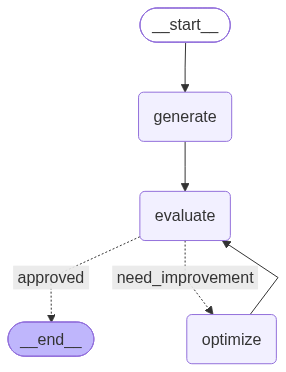

In [7]:
graph=StateGraph(TweetState)
graph.add_node("generate",generate_tweet)
graph.add_node("evaluate",evaluate_tweet)
graph.add_node("optimize",optimize_tweet)


graph.add_edge(START,"generate")
graph.add_edge("generate","evaluate")

graph.add_conditional_edges("evaluate",route_evaluation,{'approved':END,'need_improvement':"optimize"})

graph.add_edge('optimize','evaluate')

workflow=graph.compile()
workflow

In [ ]:
initial_state={
    "topic":"indian railways",
    "iteration":1,
    "max_iteration":5
}

workflow.invoke(initial_state)